[目录](./table_of_contents.ipynb)


# 卡尔曼滤波数学（Kalman Filter Math）


In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

如果你读到这里，我希望你已经觉得卡尔曼滤波（Kalman filter）那令人望而生畏的名声多少有些名不副实。诚然，我对一些方程做了“手挥”处理，但我希望实现对你来说相当直接。背后的概念很直白——取两个测量值，或一个测量值与一个预测值，让输出落在两者之间。你若更相信测量，估计值就更靠近测量；你若更相信预测更准确，估计值就更靠近预测。这可不是火箭科学（开个玩笑——正是这类数学把阿波罗送上了月球并安全返回！）。

老实说，我一直在精心挑选问题。对任意问题而言，设计卡尔曼滤波矩阵都可能极其困难。不过我也并没有太过“刁钻”。像牛顿运动方程这类式子，在卡尔曼滤波应用里可以轻而易举地算出来，而且它们构成了我们想解决的那类问题的主体。

我一直用代码和推理来阐明概念，而不是数学。但有些主题确实需要比目前更多的数学。本章给出你在本书其余部分会用到的数学。



## 动态系统建模（Modeling a Dynamic System）

*动态系统（dynamic system）* 是状态（位置、温度等）随时间演化的物理系统。微积分研究变化量，因此我们用微分方程来建模动态系统。有些系统无法用微分方程建模，但本书不会遇到那些情况。

动态系统建模本身是一门大学课程的主题。某种程度上，几学期的常微分方程与偏微分方程，再加上一门研究生水平的控制系统理论课，是无可替代的。若你是爱好者，或只是在工作中要解决某一个很具体的滤波问题，你可能没有一年或更长时间投入那种教育的意愿或必要。

幸运的是，我可以给出足够的理论，让我们能为许多不同的卡尔曼滤波器建立系统方程。我的目标是让你能阅读一篇论文并足够理解，从而能实现其中的算法。背景数学很深，但实践中我们最终只用到少数几种简单技巧。

这是本书中纯数学最长的一节。你需要掌握本节全部内容，才能理解扩展卡尔曼滤波（Extended Kalman Filter, EKF）——最常见的非线性滤波器。我也介绍了不需要这么多数学的较新滤波器。你可以选择先略读，等决定学习 EKF 时再回来细读。

我们需要从理解卡尔曼滤波所依赖的底层方程与假设开始。我们在试图对真实世界现象建模，需要考虑什么？

每个物理系统都有一个过程。例如，以一定速度行驶的汽车在固定时间内行驶一定距离，其速度随加速度变化。我们用高中就熟悉的新顿方程描述这种行为。

$$
\begin{aligned}
v&=at\\
x &= \frac{1}{2}at^2 + v_0t + x_0
\end{aligned}
$$

学过微积分后，我们看到它们写成这种形式：

$$ \mathbf v = \frac{d \mathbf x}{d t}, 
\quad \mathbf a = \frac{d \mathbf v}{d t} = \frac{d^2 \mathbf x}{d t^2}
$$

典型的汽车跟踪问题会让你在恒定速度或加速度下计算行驶距离，正如前面几章所做。当然，我们知道并非只有这些在发生。没有汽车能在完美路面上行驶。有颠簸、风阻，以及起伏改变速度的山坡。悬架是带有摩擦和不完美弹簧的机械系统。

对系统做完美建模，除了最平凡的问题外是不可能的。我们不得不做简化。在任意时刻 $t$，我们说真实状态（例如汽车位置）是不完美模型的预测值加上某种未知的 *过程噪声（process noise）*：

$$
x(t) = x_{pred}(t) + noise(t)
$$

这并不意味着 $noise(t)$ 是我们能解析推导的函数。它只是一种事实陈述——我们总可以把真实值描述为预测值加上过程噪声。“噪声”并不意味着随机事件。若我们在大气中跟踪抛出的球，而模型假设球在真空中，则空气阻力的影响在此语境下就是过程噪声。

下一节我们将学习把一组高阶微分方程转化为一组一阶微分方程的技巧。转化后，不含噪声的系统模型为：

$$ \dot{\mathbf x} = \mathbf{Ax}$$

$\mathbf A$ 称为 *系统动力学矩阵（systems dynamics matrix）*，因为它描述系统动力学。现在需要建模噪声。我们称之为 $\mathbf w$，并加入方程：

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf w$$

$\mathbf w$ 作为名字可能显得不佳，但你很快会看到卡尔曼滤波假设 *白噪声（white noise）*。

最后，需要考虑进入系统的任何输入。我们假设输入 $\mathbf u$，且存在线性模型描述该输入如何改变系统。例如，踩汽车油门使其加速，重力使球下落。二者都是控制输入。我们需要矩阵 $\mathbf B$ 把 $u$ 转化为对系统的影响。将其加入方程：

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

就是这样。这是卡尔曼博士要解决的方程之一；在假设 $\mathbf w$ 具有某些性质时，他找到了最优估计器。



## 动态系统的状态空间表示（State-Space Representation of Dynamic Systems）


我们已推导出方程

$$ \dot{\mathbf x} = \mathbf{Ax}+ \mathbf{Bu} + \mathbf{w}$$

然而，我们感兴趣的不是 $\mathbf x$ 的导数，而是 $\mathbf x$ 本身。暂且忽略噪声，我们希望有一个方程，用 $t_{k-1}$ 时刻的 $\mathbf x$ 递归求出 $t_k$ 时刻的 $\mathbf x$：

$$\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1}) + \mathbf B(t_k)\mathbf u (t_k)$$

按惯例，我们把 $\mathbf x(t_k)$ 写成 $\mathbf x_k$，表示 $\mathbf x$ 在 $t$ 的第 $k$ 个取值。

$$\mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

$\mathbf F$ 是我们熟悉的 *状态转移矩阵（state transition matrix）*，因其能在离散时间步之间转移状态值。它与系统动力学矩阵 $\mathbf A$ 非常相似。区别在于 $\mathbf A$ 建模一组线性微分方程，是连续的；$\mathbf F$ 是离散的，表示一组线性方程（不是微分方程），在离散时间步 $\Delta t$ 内把 $\mathbf x_{k-1}$ 过渡到 $\mathbf x_k$。

求这个矩阵往往相当困难。方程 $\dot x = v$ 是最简单可能的微分方程，我们可平凡地积分为：

$$ \int\limits_{x_{k-1}}^{x_k}  \mathrm{d}x = \int\limits_{0}^{\Delta t} v\, \mathrm{d}t $$
$$x_k-x_{k-1} = v \Delta t$$
$$x_k = v \Delta t + x_{k-1}$$

该方程是 *递归（recursive）* 的：我们根据 $k-1$ 时刻的 $x$ 计算 $k$ 时刻的 $x$。这种递归形式使我们能把系统（过程模型）表示成卡尔曼滤波所需的形式：

$$\begin{aligned}
\mathbf x_k &= \mathbf{Fx}_{k-1}  \\
&= \begin{bmatrix} 1 & \Delta t \\ 0 & 1\end{bmatrix}
\begin{bmatrix}x_{k-1} \\ \dot x_{k-1}\end{bmatrix}
\end{aligned}$$

我们之所以能这样做，只是因为 $\dot x = v$ 是最简单可能的微分方程。物理系统中几乎所有其他情况都会导致更复杂的微分方程，无法用这种方法处理。

*状态空间（state-space）* 方法在阿波罗任务前后流行起来，很大程度上归功于卡尔曼博士的工作。思想很简单：用一组 $n$ 阶微分方程建模系统，把它们转化为等价的一组一阶微分方程，再写成上一节所用的向量-矩阵形式：$\dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu}$。一旦写成这种形式，我们可用多种技巧把这些线性微分方程转化为递归方程：

$$ \mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

有些书把状态转移矩阵称为 *基本矩阵（fundamental matrix）*。许多人用 $\mathbf \Phi$ 代替 $\mathbf F$。偏重控制理论的资料倾向于使用这些记法。

这些称为 *状态空间方法*，因为我们用系统状态来表达微分方程的解。



### 由高阶方程构成一阶方程（Forming First Order Equations from Higher Order Equations）

许多物理系统模型需要二阶或更高阶、带控制输入 $u$ 的微分方程：

$$a_n \frac{d^ny}{dt^n} + a_{n-1} \frac{d^{n-1}y}{dt^{n-1}} +  \dots + a_2 \frac{d^2y}{dt^2} + a_1 \frac{dy}{dt} + a_0 = u$$

状态空间方法需要一阶方程。任意高阶方程组可通过为导数定义额外变量再求解，从而降为一阶。


我们做一个例子。给定系统 $\ddot{x} - 6\dot x + 9x = u$，求等价的一阶方程。为清晰起见，我对时间导数使用点记号。

第一步是把最高阶项单独放到方程一侧。

$$\ddot{x} = 6\dot x - 9x + u$$

我们定义两个新变量：

$$\begin{aligned} x_1(t) &= x \\
x_2(t) &= \dot x
\end{aligned}$$

现在把这些代入原方程并求解。解得一组用新变量表示的一阶方程。为记法方便，惯例省略 $(t)$。

我们知道 $\dot x_1 = x_2$，且 $\dot x_2 = \ddot{x}$。因此

$$\begin{aligned}
\dot x_2 &= \ddot{x} \\
         &= 6\dot x - 9x + u\\
         &= 6x_2-9x_1 + u
\end{aligned}$$

因此一阶方程组为

$$\begin{aligned}\dot x_1 &= x_2 \\
\dot x_2 &= 6x_2-9x_1 + u\end{aligned}$$

多练习几次你就会熟练。把最高阶项单独列出，定义新变量及其导数，再代入。



### 状态空间形式的一阶微分方程（First Order Differential Equations In State-Space Form）

把上一节新定义的变量代入：

$$\frac{dx_1}{dt} = x_2,\,  
\frac{dx_2}{dt} = x_3, \, ..., \, 
\frac{dx_{n-1}}{dt} = x_n$$

得到一阶方程：

$$\frac{dx_n}{dt} = \frac{1}{a_n}\sum\limits_{i=0}^{n-1}a_ix_{i+1} + \frac{1}{a_n}u
$$


用向量-矩阵记法：

$$\begin{bmatrix}\frac{dx_1}{dt} \\ \frac{dx_2}{dt} \\ \vdots \\ \frac{dx_n}{dt}\end{bmatrix} = 
\begin{bmatrix}\dot x_1 \\ \dot x_2 \\ \vdots \\ \dot x_n\end{bmatrix}=
\begin{bmatrix}0 & 1 & 0 &\cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
-\frac{a_0}{a_n} & -\frac{a_1}{a_n} & -\frac{a_2}{a_n} & \cdots & -\frac{a_{n-1}}{a_n}\end{bmatrix}
\begin{bmatrix}x_1 \\ x_2 \\ \vdots \\ x_n\end{bmatrix} + 
\begin{bmatrix}0 \\ 0 \\ \vdots \\ \frac{1}{a_n}\end{bmatrix}u$$

再写成 $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{B}u$。



### 时不变系统的基本矩阵（Finding the Fundamental Matrix for Time Invariant Systems）

我们把系统方程写成状态空间形式

$$ \dot{\mathbf x} = \mathbf{Ax}$$

其中 $\mathbf A$ 是系统动力学矩阵，并希望找到 *基本矩阵（fundamental matrix）* $\mathbf F$，用方程在区间 $\Delta t$ 上传播状态 $\mathbf x$：

$$\begin{aligned}
\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1})\end{aligned}$$

换言之，$\mathbf A$ 是一组连续微分方程，我们需要 $\mathbf F$ 是一组离散线性方程，计算 $\mathbf A$ 在离散时间步上的变化。

惯例省略 $t_k$ 和 $(\Delta t)$，记作

$$\mathbf x_k = \mathbf {Fx}_{k-1}$$

概括而言，卡尔曼滤波文献与实践中求该矩阵有三种常见方法。最常用的是矩阵指数。线性时不变理论（Linear Time Invariant Theory），也称 LTI 系统理论，是第二种。最后是数值技巧。你可能还知道其他方法，但这三种是你在卡尔曼滤波文献与实践中最常遇到的。



### 矩阵指数（The Matrix Exponential）

方程 $\frac{dx}{dt} = kx$ 的解可求为：

$$\begin{gathered}\frac{dx}{dt} = kx \\
\frac{dx}{x} = k\, dt \\
\int \frac{1}{x}\, dx = \int k\, dt \\
\log x = kt + c \\
x = e^{kt+c} \\
x = e^ce^{kt} \\
x = c_0e^{kt}\end{gathered}$$

当 $t=0$，$x=x_0$。代入上式。

$$\begin{gathered}x_0 = c_0e^{k(0)} \\
x_0 = c_01 \\
x_0 = c_0 \\
x = x_0e^{kt}\end{gathered}$$

用类似数学，一阶方程

$$\dot{\mathbf x} = \mathbf{Ax} ,\, \, \, \mathbf x(0) = \mathbf x_0$$

其中 $\mathbf A$ 为常数矩阵，其解为

$$\mathbf x = e^{\mathbf At}\mathbf x_0$$

代入 $F = e^{\mathbf At}$，可写

$$\mathbf x_k = \mathbf F\mathbf x_{k-1}$$

这正是我们需要的形式！求基本矩阵的问题化为求 $e^{\mathbf At}$。

$e^{\mathbf At}$ 称为 [矩阵指数（matrix exponential）](https://en.wikipedia.org/wiki/Matrix_exponential)。可用幂级数计算：

$$e^{\mathbf At} = \mathbf{I} + \mathbf{A}t  + \frac{(\mathbf{A}t)^2}{2!} + \frac{(\mathbf{A}t)^3}{3!} + ... $$

该级数通过对 $e^{\mathbf At}$ 做泰勒级数展开得到，此处不展开。

我们用此法求牛顿方程的解。用 $v$ 代替 $\dot x$，并假设恒定速度，得到线性矩阵-向量形式

$$\begin{bmatrix}\dot x \\ \dot v\end{bmatrix} =\begin{bmatrix}0&1\\0&0\end{bmatrix} \begin{bmatrix}x \\ v\end{bmatrix}$$

这是一阶微分方程，可设 $\mathbf{A}=\begin{bmatrix}0&1\\0&0\end{bmatrix}$ 并求解下列方程。我用区间 $\Delta t$ 代替 $t$，强调基本矩阵是离散的：

$$\mathbf F = e^{\mathbf A\Delta t} = \mathbf{I} + \mathbf A\Delta t  + \frac{(\mathbf A\Delta t)^2}{2!} + \frac{(\mathbf A\Delta t)^3}{3!} + ... $$

若做矩阵乘法，会发现 $\mathbf{A}^2=\begin{bmatrix}0&0\\0&0\end{bmatrix}$，即 $\mathbf{A}$ 的更高次幂也为 $\mathbf{0}$。因此无需无穷多项即得精确答案：

$$
\begin{aligned}
\mathbf F &=\mathbf{I} + \mathbf A \Delta t + \mathbf{0} \\
&= \begin{bmatrix}1&0\\0&1\end{bmatrix} + \begin{bmatrix}0&1\\0&0\end{bmatrix}\Delta t\\
&= \begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}
\end{aligned}$$

代入 $\mathbf x_k= \mathbf{Fx}_{k-1}$ 得

$$
\begin{aligned}
x_k &=\begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}x_{k-1}
\end{aligned}$$

你会认出这正是 **多元卡尔曼滤波（Multivariate Kalman Filter）** 一章中解析推导的恒定速度卡尔曼滤波矩阵。

SciPy 的 `linalg` 模块有 `expm()` 计算矩阵指数。它不用泰勒级数，而用 [Padé 逼近（Padé Approximation）](https://en.wikipedia.org/wiki/Pad%C3%A9_approximant)。计算矩阵指数的方法很多（至少 19 种），都存在数值困难[1]。当 $\mathbf A$ 较大时尤其要注意这些问题。若搜索 "pade approximation matrix exponential" 会找到大量相关论文。

实践中，对卡尔曼滤波我们通常只取泰勒级数前两项。但不要以为我这里处理已完备，就去把该技巧用于其他问题而不做数值性能分析。有趣的是，求解 $e^{\mathbf At}$ 的常用方法之一是用广义 ODE 求解器——换言之，与我们相反：把 $\mathbf A$ 变成一组微分方程，再用数值方法求解！

下面是用 `expm()` 求解 $e^{\mathbf At}$ 的例子。



In [3]:
import numpy as np
from scipy.linalg import expm

dt = 0.1
A = np.array([[0, 1], 
              [0, 0]])
expm(A*dt)

array([[1. , 0.1],
       [0. , 1. ]])

### 时不变性（Time Invariance）

若系统行为依赖时间，可说动态系统由一阶微分方程描述

$$ g(t) = \dot x$$

若系统是 *时不变（time invariant）*，方程形如：

$$ f(x) = \dot x$$

*时不变* 是什么意思？考虑家用音响。若在时刻 $t$ 输入信号 $x$，会输出某信号 $f(x)$。若在 $t + \Delta t$ 再输入，输出仍是同一 $f(x)$，只是时间平移。

反例是 $x(t) = \sin(t)$，系统 $f(x) = t\,  x(t) = t \sin(t)$。这不是时不变的；因乘以 $t$，不同时刻值不同。飞机也不是时不变的。若较晚时刻对飞机做控制输入，行为会不同，因为已消耗燃料、重量减轻。重量降低导致行为不同。

可对两边积分求解这些方程。上面我对时不变系统 $v = \dot x$ 演示了积分。但对时不变方程 $\dot x = f(x)$ 积分就不那么简单。用 *变量分离（separation of variables）* 技巧，两边除以 $f(x)$，把 $dt$ 移到右边再分别积分：

$$\begin{gathered}
\frac{dx}{dt} = f(x) \\
\int^x_{x_0} \frac{1}{f(x)} dx = \int^t_{t_0} dt
\end{gathered}$$

令 $F(x) = \int \frac{1}{f(x)} dx$，得

$$F(x) - F(x_0) = t-t_0$$

再对 $x$ 求解：

$$\begin{gathered}
F(x) = t - t_0 + F(x_0) \\
x = F^{-1}[t-t_0 + F(x_0)]
\end{gathered}$$

换言之，需要求 $F$ 的逆。这并不平凡，理工科教育中有大量课程致力于求这类棘手解析解。

然而，它们终究是“技巧”，许多简单形式的 $f(x)$ 要么没有闭式解，要么极其困难。实践中，工程师转向状态空间方法求近似解。

矩阵指数的优点是可用于任意 *时不变* 微分方程组。但我们常在方程并非严格时不变时仍用该技巧。飞机飞行时消耗燃料、减轻重量。但一秒钟内的减重可忽略，故该时间步内系统近似线性。只要时间步足够短，结果仍相当准确。



#### 示例：质量-弹簧-阻尼器模型（Mass-Spring-Damper Model）

假设要跟踪弹簧上质量块、并连接阻尼器的运动，例如汽车悬架。在质量 $m$、弹簧常数 $k$、阻尼力 $c$ 及输入 $u$ 下，运动方程为

$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} +kx = u$$

为记法方便写成

$$m\ddot x + c\dot x + kx = u$$

设 $x_1(t)=x(t)$ 可化为一阶方程组：

$$\begin{aligned}
x_1 &= x \\
x_2 &= \dot x_1 \\
\dot x_2 &= \ddot x_1 = \ddot x
\end{aligned}$$

惯例省略 $(t)$。得到方程

$$m\dot x_2 + c x_2 +kx_1 = u$$

对 $\dot x_2$ 求解得一阶方程：

$$\dot x_2 = -\frac{c}{m}x_2 - \frac{k}{m}x_1 + \frac{1}{m}u$$

写成矩阵形式：

$$\begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix} = 
\begin{bmatrix}0 & 1 \\ -k/m & -c/m \end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + 
\begin{bmatrix} 0 \\ 1/m \end{bmatrix}u$$

再用矩阵指数求状态转移矩阵：

$$\Phi(t) = e^{\mathbf At} = \mathbf{I} + \mathbf At  + \frac{(\mathbf At)^2}{2!} + \frac{(\mathbf At)^3}{3!} + ... $$

前两项给出

$$\mathbf F = \begin{bmatrix}1 & t \\ -(k/m) t & 1-(c/m) t \end{bmatrix}$$

精度是否足够要看情况。可对常数计算 $\frac{(\mathbf At)^2}{2!}$，看该矩阵对结果贡献多少。



### 线性时不变理论（Linear Time Invariant Theory）

[*线性时不变理论（Linear Time Invariant Theory）*](https://en.wikipedia.org/wiki/LTI_system_theory)，也称 LTI 系统理论，提供用逆拉普拉斯变换求 $\Phi$ 的方法。你可能点头，也可能完全懵。本书不会使用拉普拉斯变换。LTI 系统理论告诉我们

$$ \Phi(t) = \mathcal{L}^{-1}[(s\mathbf{I} - \mathbf{A})^{-1}]$$

我不打算深入，只说明拉普拉斯变换 $\mathcal{L}$ 把信号变到不含时间的 $s$ 空间，但求上式解并不平凡。若感兴趣，维基百科 LTI 系统理论条目可作入门。我提及 LTI 是因为你会在文献里看到有人用它为困难问题设计卡尔曼滤波矩阵。



### 数值解（Numerical Solutions）

最后，还有求 $\mathbf F$ 的数值技巧。滤波器变大时，解析解变得非常繁琐（尽管 SymPy 等包能简化）。C. F. van Loan [2] 发展了一种同时数值计算 $\Phi$ 与 $\mathbf Q$ 的方法。给定连续模型

$$ \dot x = Ax + Gw$$

其中 $w$ 为单位白噪声，van Loan 方法计算 $\mathbf F_k$ 与 $\mathbf Q_k$。
    
我已在 `FilterPy` 中实现 van Loan 方法。用法如下：

```python
from filterpy.common import van_loan_discretization

A = np.array([[0., 1.], [-1., 0.]])
G = np.array([[0.], [2.]]) # white noise scaling
F, Q = van_loan_discretization(A, G, dt=0.1)
```
    
在 *微分方程的数值积分（Numeric Integration of Differential Equations）* 一节，我会介绍卡尔曼滤波中非常常用的替代方法。



## 过程噪声矩阵 $\mathbf Q$ 的设计（Design of the Process Noise Matrix）

一般而言，设计 $\mathbf Q$ 矩阵是卡尔曼滤波设计中最难的方面之一。原因有几方面。首先，数学需要扎实的信号理论基础。其次，我们在为信息很少的事物建模噪声。考虑为抛出的棒球建模过程噪声：可建模为空气中运动的球体，但仍有许多未知因素——球旋转与自旋衰减、缝线球的阻力系数、风与空气密度影响等。我们为给定过程模型推导精确数学解的方程，但过程模型不完整，$\mathbf Q$ 的结果也不完整。这对卡尔曼滤波行为影响很大。若 $\mathbf Q$ 太小，滤波器会过度自信于预测模型而偏离真实解。若 $\mathbf Q$ 太大，滤波器会过度受测量噪声影响，表现次优。实践中我们花大量时间做仿真、评估采集数据，以选择合适的 $\mathbf Q$。但先从数学看起。


假设运动学系统——可用牛顿运动方程建模的系统。对该过程可做几种不同假设。

我们一直用的过程模型为

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

其中 $\mathbf w$ 是过程噪声。运动学系统是 *连续* 的——输入输出可在任意时刻变化。但我们的卡尔曼滤波是 *离散* 的（连续形式卡尔曼滤波存在，本书不涵盖）。我们按固定间隔采样。因此必须求上式噪声项的离散表示，这取决于对噪声行为的假设。下面考虑两种噪声模型。



### 连续白噪声模型（Continuous White Noise Model）


我们用牛顿方程建模运动学系统。状态模型用过位置与速度，或位置、速度与加速度。理论上还可继续——建模 jerk、jounce、snap 等。通常不这样做，因为超出真实系统动力学的项会恶化估计。

假设需要建模位置、速度与加速度。可假设每个离散时间步内加速度恒定。当然，系统有过程噪声，加速度并非真正恒定。被跟踪物体会因未建模外力而改变加速度。本节假设加速度由连续时间零均值白噪声 $w(t)$ 改变。换言之，我们假设速度的小变化在时间平均上为 0（零均值）。

因噪声连续变化，需积分才能得到所选离散化区间的离散噪声。此处不证明，离散化噪声方程为

$$\mathbf Q = \int_0^{\Delta t} \mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t) dt$$

其中 $\mathbf{Q_c}$ 是连续噪声。推理应清楚：$\mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t)$ 是根据过程模型 $\mathbf F(t)$ 在时刻 $t$ 对连续噪声的投影。我们想知道区间 $[0, \Delta t]$ 内系统增加多少噪声，故对该式积分。

牛顿系统的基本矩阵为

$$F = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

连续噪声定义为

$$\mathbf{Q_c} = \begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix} \Phi_s$$

其中 $\Phi_s$ 是白噪声的谱密度（spectral density）。这可推导，但超出本书范围。详见任何标准随机过程教材。实践中我们常不知噪声谱密度，于是它变成“工程”因子——实验调参直到滤波器表现符合预期。可见 $\Phi_s$ 所乘矩阵 effectively 把功率谱密度赋给加速度项。这合理：我们假设系统加速度恒定，除噪声引起的变化外。噪声改变加速度。

可自行计算，但我更喜欢用 SymPy 求解。

$$\mathbf{Q_c} = \begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix} \Phi_s$$





In [4]:
import sympy
from sympy import (init_printing, Matrix, MatMul, 
                   integrate, symbols)

init_printing(use_latex='mathjax')
dt, phi = symbols('\Delta{t} \Phi_s')
F_k = Matrix([[1, dt, dt**2/2],
              [0,  1,      dt],
              [0,  0,       1]])
Q_c = Matrix([[0, 0, 0],
              [0, 0, 0],
              [0, 0, 1]])*phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

⎡         5           4           3⎤      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥      
⎢    20          8           6     ⎥      
⎢                                  ⎥      
⎢         4           3           2⎥      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥⋅\Phiₛ
⎢    8           3           2     ⎥      
⎢                                  ⎥      
⎢         3           2            ⎥      
⎢\Delta{t}   \Delta{t}             ⎥      
⎢──────────  ──────────  \Delta{t} ⎥      
⎣    6           2                 ⎦      

为完整起见，我们计算 0 阶与 1 阶方程的式子。


In [5]:
F_k = Matrix([[1]])
Q_c = Matrix([[phi]])

print('0th order discrete process noise')
integrate(F_k*Q_c*F_k.T,(dt, 0, dt))

0th order discrete process noise


[\Delta{t}⋅\Phiₛ]

In [6]:
F_k = Matrix([[1, dt],
              [0, 1]])
Q_c = Matrix([[0, 0],
              [0, 1]]) * phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

print('1st order discrete process noise')
# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

1st order discrete process noise


⎡         3           2⎤      
⎢\Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────⎥      
⎢    3           2     ⎥      
⎢                      ⎥⋅\Phiₛ
⎢         2            ⎥      
⎢\Delta{t}             ⎥      
⎢──────────  \Delta{t} ⎥      
⎣    2                 ⎦      

### 分段白噪声模型（Piecewise White Noise Model）

另一种噪声模型假设：最高阶项（如加速度）在每个时间段内恒定，但各段不同，且段间不相关。换言之，每个时间步加速度有不连续跳变。这与上节微妙不同——上节假设最后一项施加连续变化的噪声信号。

建模为

$$f(x)=Fx+\Gamma w$$

其中 $\Gamma$ 是系统的 *噪声增益（noise gain）*，$w$ 是恒定的分段加速度（或速度、jerk 等）。

先看一阶系统。状态转移函数为

$$\mathbf{F} = \begin{bmatrix}1&\Delta t \\ 0& 1\end{bmatrix}$$

在一个时间段内，速度变化为 $w(t)\Delta t$，位置变化为 $w(t)\Delta t^2/2$，故

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\end{bmatrix}$$

过程噪声协方差为

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$.

可用 SymPy 计算如下



In [7]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3⎤    
⎢\Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────⎥    
⎢    4           2     ⎥    
⎢                      ⎥⋅σ²ᵥ
⎢         3            ⎥    
⎢\Delta{t}            2⎥    
⎢──────────  \Delta{t} ⎥    
⎣    2                 ⎦    

二阶系统用同样数学处理。


$$\mathbf{F} = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

这里假设白噪声为离散时间维纳过程（Wiener process）。于是

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\\ 1\end{bmatrix}$$

该模型并无“真理”可言，只是方便且结果良好。例如，也可假设噪声作用于 jerk，代价是方程更复杂。

过程噪声协方差为

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$.

可用 SymPy 计算如下



In [8]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt], [1]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3           2⎤    
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────  ──────────⎥    
⎢    4           2           2     ⎥    
⎢                                  ⎥    
⎢         3                        ⎥    
⎢\Delta{t}            2            ⎥    
⎢──────────  \Delta{t}   \Delta{t} ⎥⋅σ²ᵥ
⎢    2                             ⎥    
⎢                                  ⎥    
⎢         2                        ⎥    
⎢\Delta{t}                         ⎥    
⎢──────────  \Delta{t}       1     ⎥    
⎣    2                             ⎦    

不能说该模型比连续模型更正确或更错误——二者都是对真实物体行为的近似。只有经验与实验能指导你选择合适模型。实践中常发现两种模型都给出合理结果，但通常一种优于另一种。

第二种模型的优点是用 $\sigma^2$ 描述噪声，可用运动与预期误差表述。第一种需指定谱密度，不够直观，但对变化时间采样处理更好，因噪声在时间段上积分。但这些不是铁律——根据滤波表现和/或对物理模型的了解，选用任一模型或自建模型。

经验法则是把 $\sigma$ 设在 $\frac{1}{2}\Delta a$ 到 $\Delta a$ 之间，其中 $\Delta a$ 是采样周期间加速度的最大变化量。实践中选一个数，对数据做仿真，选表现好的值。



### 用 FilterPy 计算 $\mathbf Q$（Using FilterPy to Compute Q）

FilterPy 提供若干计算 $\mathbf Q$ 的例程。`Q_continuous_white_noise()` 根据 $\Delta t$ 与谱密度计算 $\mathbf Q$。



In [9]:
from filterpy.common import Q_continuous_white_noise
from filterpy.common import Q_discrete_white_noise

Q = Q_continuous_white_noise(dim=2, dt=1, spectral_density=1)
print(Q)

[[0.333 0.5  ]
 [0.5   1.   ]]


In [10]:
Q = Q_continuous_white_noise(dim=3, dt=1, spectral_density=1)
print(Q)

[[0.05  0.125 0.167]
 [0.125 0.333 0.5  ]
 [0.167 0.5   1.   ]]


函数 `Q_discrete_white_noise()` 在假设分段噪声模型下计算 $\mathbf Q$。


In [11]:
Q = Q_discrete_white_noise(2, var=1.)
print(Q)

[[0.25 0.5 ]
 [0.5  1.  ]]


In [12]:
Q = Q_discrete_white_noise(3, var=1.)
print(Q)

[[0.25 0.5  0.5 ]
 [0.5  1.   1.  ]
 [0.5  1.   1.  ]]


### $\mathbf Q$ 的简化（Simplification of Q）

许多处理对 $\mathbf Q$ 用更简单形式：除右下角噪声项外全置零。这合理吗？考虑小 $\Delta t$ 时 $\mathbf Q$ 的值



In [13]:
import numpy as np

np.set_printoptions(precision=8)
Q = Q_continuous_white_noise(
    dim=3, dt=0.05, spectral_density=1)
print(Q)
np.set_printoptions(precision=3)

[[0.00000002 0.00000078 0.00002083]
 [0.00000078 0.00004167 0.00125   ]
 [0.00002083 0.00125    0.05      ]]


可见大多数项非常小。回忆唯一使用该矩阵的方程是

$$ \mathbf P=\mathbf{FPF}^\mathsf{T} + \mathbf Q$$

若 $\mathbf Q$ 相对 $\mathbf P$ 很小，则对 $\mathbf P$ 的计算几乎无贡献。把 $\mathbf Q$ 置零，仅保留右下角项

$$\mathbf Q=\begin{bmatrix}0&0&0\\0&0&0\\0&0&\sigma^2\end{bmatrix}$$

虽不正确，常是有用的近似。对重要应用需做大量研究以保证滤波器在各种情况下工作。

若这样做，“右下角项”指每个变量变化最快的项。若状态为 $x=\begin{bmatrix}x & \dot x & \ddot{x} & y & \dot{y} & \ddot{y}\end{bmatrix}^\mathsf{T}$，则 $\mathbf Q$ 为 6×6；$\ddot{x}$ 与 $\ddot{y}$ 对应元素须设为非零。



## 后验协方差（posterior covariance）的稳定计算（Stable Compution of the Posterior Covariance）

我曾给出后验协方差计算式

$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$$

严格说正确，但 `FilterPy` 中我用的是 *Joseph* 方程


$$\mathbf P = (\mathbf I-\mathbf {KH})\mathbf{\bar P}(\mathbf I-\mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$$


我常收到邮件和/或 GitHub issue，声称实现有 bug。不是 bug，我用它有几个原因。首先，减法 $(\mathbf I - \mathbf{KH})$ 可能因浮点误差导致矩阵非对称。协方差必须对称，非对称常导致卡尔曼滤波发散，甚至因 NumPy 内置检查而抛异常。

保持对称的传统做法是：

$$\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$

这安全，因为协方差矩阵中 $\sigma_{ij} = \sigma_{ji}$。该运算对因浮点误差而偏离的两个值取平均。

若看上面 Joseph 形式，两项都有类似的 $\mathbf{ABA}^\mathsf T$ 结构，故都保持对称。但该式从何而来？为何不用


$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P} \\
\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$


我们从第一原理推导。并不太难，需理解推导才能理解方程目的，更重要的是在滤波因数值不稳定发散时诊断问题。推导来自 Brown[4]。

先介绍符号。$\mathbf x$ 是系统真实状态。$\mathbf{\hat x}$ 是估计状态——后验。$\mathbf{\bar x}$ 是先验估计。

由此定义模型为

$$\mathbf x_{k+1} = \mathbf F_k \mathbf x_k + \mathbf w_k \\
\mathbf z_k = \mathbf H_k \mathbf x_k + \mathbf v_k$$

换言之，系统下一状态 $\mathbf x_{k+1}$ 是当前状态 $k$ 经过程 $\mathbf F_k$ 移动，再加噪声 $\mathbf w_k$。

注意这些是定义。没有系统完美遵循数学模型，故用噪声项 $\mathbf w_k$ 建模。测量也不完美（传感器误差），用 $\mathbf v_k$ 建模。

下文省略下标 $k$，因推导中只考虑 $k$ 步，不考虑 $k+1$。

估计误差定义为真实状态与估计状态之差

$$ \mathbf e = \mathbf x - \mathbf{\hat x}$$

这又是定义；我们不知如何算 $\mathbf e$，只是定义真实与估计的差。

于是可定义估计的协方差，为 $\mathbf{ee}^\mathsf T$ 的期望值：

$$\begin{aligned}
P &= E[\mathbf{ee}^\mathsf T] \\
&= E[(\mathbf x - \mathbf{\hat x})(\mathbf x - \mathbf{\hat x})^\mathsf T]
\end{aligned}$$


再定义后验估计为

$$\mathbf {\hat x} = \mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})$$

看起来像卡尔曼滤波方程，确有原因。但迄今的数学都是 **定义**。特别地，我们尚未定义 $\mathbf K$，不要把它想成卡尔曼增益，因为我们在解 *任意* 问题，不限于线性卡尔曼滤波。这里 $\mathbf K$ 只是 0 到 1 之间某个未指定的混合值。



有了定义，做代入与代数。

项 $(\mathbf x - \mathbf{\hat x})$ 可用上式替换 $\mathbf{\hat x}$ 展开：

$$(\mathbf x - \mathbf{\hat x}) = \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x}))$$

再把 $\mathbf z$ 换成 $\mathbf H \mathbf x + \mathbf v$：

$$\begin{aligned}
(\mathbf x - \mathbf{\hat x})
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})) \\
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x})) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x}) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf{KH}(\mathbf x - \mathbf{ \bar x}) - \mathbf{Kv} \\
&=  (\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}
\end{aligned}$$

注意 $(\mathbf x - \mathbf{\bar x})$ 的期望是先验协方差 $\mathbf{\bar P}$，$\mathbf v$ 的期望为 $E[\mathbf{vv}^\mathbf T] = \mathbf R$，可解 $\mathbf P$：

$$\begin{aligned}
\mathbf P &= 
   E\big[[(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv})]
  [(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}]^\mathsf T\big ] \\
  &= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T
\end{aligned}$$

这正是我们要证的。

注意该式对 *任意* $\mathbf K$ 成立，不限于卡尔曼滤波算出的最优 $\mathbf K$。这也是我用该方程的原因。实践中滤波器算出的卡尔曼增益 *并非* 最优，既因真实世界并非严格线性高斯，也因计算带来的浮点误差。该方程在真实条件下更不易使滤波发散。

那么 $\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ 从何而来？完成推导很简单。回忆卡尔曼滤波（最优）增益为

$$\mathbf K = \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}$$

代入刚推导的方程：

$$\begin{aligned}
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf K(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T \\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P}\\
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}
\end{aligned}$$

因此当增益最优时 $\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ 数学上正确，但 $(\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$ 也正确。如前所述，后者在增益次优时也正确，且数值更稳定。故 FilterPy 用该计算。

滤波器仍可能发散，尤其运行数百或数千个 epoch。需审视这些方程。文献还有该计算的其他形式，可能更适合你的问题。一如既往，若解决真实工程问题且失败可能造成设备或生命损失，需超越本书查阅工程文献。若做“玩具”问题、失败无害，检测到发散可把 $\mathbf P$ 重置为“合理”值继续。例如可把非对角元清零，矩阵只含方差，再或许乘以略大于 1 的常数反映刚注入的信息损失。发挥想象并测试。



## 推导卡尔曼增益方程（Deriving the Kalman Gain Equation）

若读了上一节，不妨也读本节。读完我们就推导完卡尔曼滤波方程。

注意该推导 *不* 使用贝叶斯方程。我见过至少四种推导卡尔曼滤波方程的方法；本推导典型于文献，并承接上一节。来源仍是 Brown [4]。

上一节用未指定缩放因子 $\mathbf K$ 推导了 Joseph 协方差形式。若要最优滤波，需用微积分最小化方程误差。你应熟悉该思想：求 $f(x)$ 最小值，求导并令其为零：$\frac{x}{dx}f(x) = 0$。

我们的误差由协方差矩阵 $\mathbf P$ 表达。特别地，对角元表达状态向量各元素的误差（方差）。因此求最优增益要对对角线之和（迹）求导。

Brown 提醒两个涉及迹导数的公式：

$$\frac{d\, trace(\mathbf{AB})}{d\mathbf A} = \mathbf B^\mathsf T$$

$$\frac{d\, trace(\mathbf{ACA}^\mathsf T)}{d\mathbf A} = 2\mathbf{AC}$$

其中 $\mathbf{AB}$ 为方阵，$\mathbf C$ 对称。


展开 Joseph 方程：

$$\mathbf P = \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T + \mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)\mathbf K^\mathsf T$$

现在对 $\mathbf P$ 的迹关于 $\mathbf K$ 求导：$\frac{d\, trace(\mathbf P)}{d\mathbf K}$。

第一项不含 $\mathbf K$，迹的导数为 $0$。

第二项迹的导数为 $(\mathbf H\mathbf{\bar P})^\mathsf T$。

第三项注意到 $\mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T$ 是 $\mathbf{KH}\mathbf{\bar P}$ 的转置。矩阵的迹等于其转置的迹，故导数与第二项相同。

第四项迹的导数为 $2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$。

最终得

$$\frac{d\, trace(\mathbf P)}{d\mathbf K} = -2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$$

令其为零并求解最小化误差的 $\mathbf K$ 方程：

$$-2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = 0 \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = (\mathbf H\mathbf{\bar P})^\mathsf T \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = \mathbf{\bar P}\mathbf H^\mathsf T \\
\mathbf K= \mathbf{\bar P}\mathbf H^\mathsf T (\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)^{-1}
$$

该推导并非无懈可击——我略去了为何最小化迹即最小化总误差的论证，但对本书应足够。任何标准教材会写得更细。



## 微分方程的数值积分（Numeric Integration of Differential Equations）


我们已接触几种求解线性微分方程的数值技巧，包括状态空间方法、拉普拉斯变换与 van Loan 方法。

它们对线性常微分方程（ODE）效果好，但对非线性方程效果差。例如，预测急转弯汽车的位置：汽车通过转前轮操纵，绕后轴枢转前进，路径连续变化，线性预测必然不正确。若相对 $\Delta t$ 系统变化足够小，常仍可得够用结果，但后续研究的非线性卡尔曼滤波很少如此。

因此需要知道如何数值积分 ODE。这可是一门需多本书的大话题。我只介绍几种简单技巧，适用于你遇到的大多数问题。




### 欧拉方法（Euler's Method）

设有初值问题

$$\begin{gathered}
y' = y, \\ y(0) = 1
\end{gathered}$$

我们恰好知道精确答案是 $y=e^t$（前面解过），但对任意 ODE 我们不知道精确解。一般只知道方程导数，即斜率。还知道初值：$t=0$ 时 $y=1$。若知道这两件事，可用 $t=0$ 的斜率与 $y(0)$ 预测 $y(t=1)$。下图已画出。



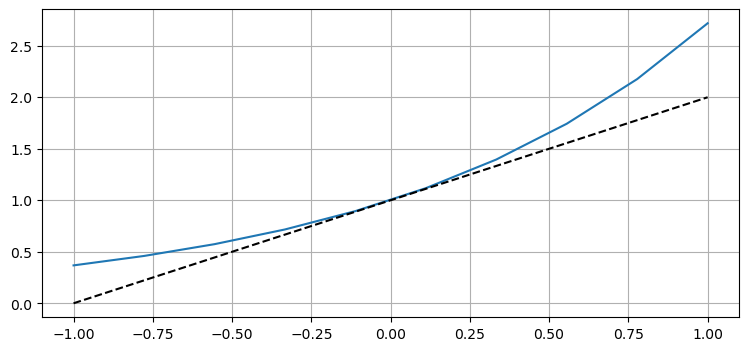

In [14]:
import matplotlib.pyplot as plt

t = np.linspace(-1, 1, 10)
plt.plot(t, np.exp(t))
t = np.linspace(-1, 1, 2)
plt.plot(t,t+1, ls='--', c='k');

可见 $t=0.1$ 时斜率很接近曲线，$t=1$ 时则差很远。但暂且继续步长为 1。可见 $t=1$ 时 $y$ 的估计值为 2。可用 $t=1$ 处曲线斜率加初值估计 $t=2$ 的值。斜率由 $y'=y$ 计算，故为 2。



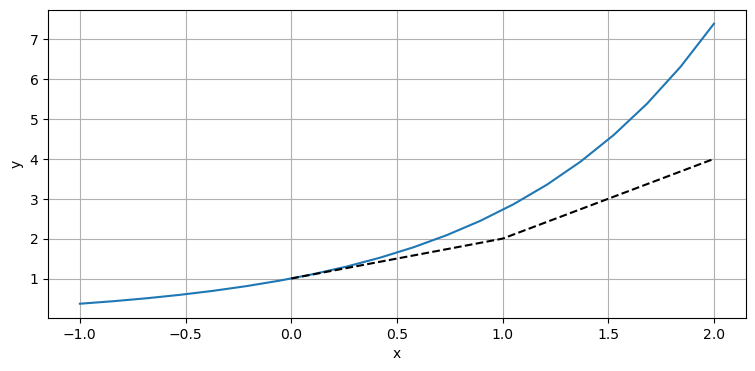

In [15]:
import kf_book.book_plots as book_plots

t = np.linspace(-1, 2, 20)
plt.plot(t, np.exp(t))
t = np.linspace(0, 1, 2)
plt.plot([1, 2, 4], ls='--', c='k')
book_plots.set_labels(x='x', y='y');

可见 $y$ 的下一估计为 4。误差迅速变大，你可能不以为然。但 1 是很大的步长。把算法写成代码，用小步长验证。



In [16]:
def euler(t, tmax, y, dx, step=1.):
    ys = []
    while t < tmax:
        y = y + step*dx(t, y)
        ys.append(y)
        t +=step        
    return ys

In [17]:
def dx(t, y): return y

print(euler(0, 1, 1, dx, step=1.)[-1])
print(euler(0, 2, 1, dx, step=1.)[-1])

2.0
4.0


看起来正确。现在用更小步长画图。


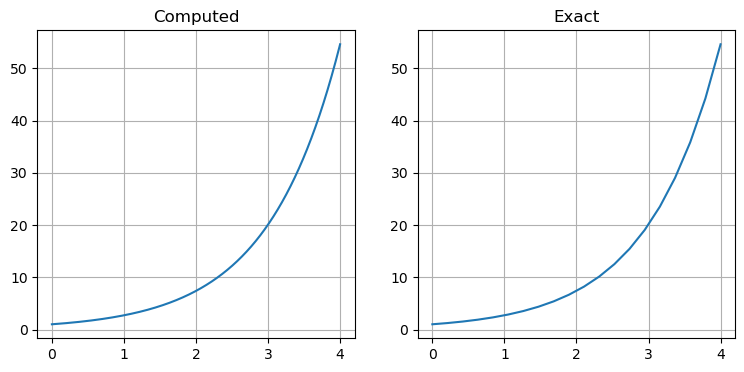

In [18]:
ys = euler(0, 4, 1, dx, step=0.00001)
plt.subplot(1,2,1)
plt.title('Computed')
plt.plot(np.linspace(0, 4, len(ys)),ys)
plt.subplot(1,2,2)
t = np.linspace(0, 4, 20)
plt.title('Exact')
plt.plot(t, np.exp(t));

In [19]:
print('exact answer=', np.exp(4))
print('euler answer=', ys[-1])
print('difference =', np.exp(4) - ys[-1])
print('iterations =', len(ys))

exact answer= 54.598150033144236
euler answer= 54.59705808834125
difference = 0.0010919448029866885
iterations = 400000


可见误差相当小，但需要大量迭代才得到三位精度。实践中欧拉方法对大多数问题太慢，我们用更高级方法。

继续之前，正式推导欧拉方法，它是下一节更高级 Runge-Kutta 方法的基础。事实上，欧拉方法是最简单的 Runge-Kutta 形式。


这是 $y$ 泰勒展开的前 3 项。无穷展开给出精确答案，$O(h^4)$ 表示有限展开带来的误差。

$$y(t_0 + h) = y(t_0) + h y'(t_0) + \frac{1}{2!}h^2 y''(t_0) + \frac{1}{3!}h^3 y'''(t_0) +  O(h^4)$$

可见欧拉方法使用泰勒展开前两项。后续项依次更小，故可确信估计不会偏离正确值太远。



### Runge-Kutta 方法（Runge Kutta Methods）



Runge-Kutta 是数值积分的主力。文献中有大量方法。实践中，这里给出的 Runge-Kutta 算法能解决你面临的几乎所有问题。它在速度、精度与稳定性之间平衡很好，除非有充分理由选别的，它是数值积分的“首选”。

深入来看。从某微分方程出发

$$\ddot{y} = \frac{d}{dt}\dot{y}$$.

可把 $y$ 的导数换成函数 $f$：

$$\ddot{y} = \frac{d}{dt}f(y,t)$$.



推导这些方程超出本书范围，但 Runge-Kutta RK4 方法定义为：

$$y(t+\Delta t) = y(t) + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) + O(\Delta t^4)$$

$$\begin{aligned}
k_1 &= f(y,t)\Delta t \\
k_2 &= f(y+\frac{1}{2}k_1, t+\frac{1}{2}\Delta t)\Delta t \\
k_3 &= f(y+\frac{1}{2}k_2, t+\frac{1}{2}\Delta t)\Delta t \\
k_4 &= f(y+k_3, t+\Delta t)\Delta t
\end{aligned}
$$

对应代码如下：



In [20]:
def runge_kutta4(y, x, dx, f):
    """computes 4th order Runge-Kutta for dy/dx.
    y is the initial value for y
    x is the initial value for x
    dx is the difference in x (e.g. the time step)
    f is a callable function (y, x) that you supply 
    to compute dy/dx for the specified values.
    """
    
    k1 = dx * f(y, x)
    k2 = dx * f(y + 0.5*k1, x + 0.5*dx)
    k3 = dx * f(y + 0.5*k2, x + 0.5*dx)
    k4 = dx * f(y + k3, x + dx)
    
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6.

用这个简单例子。设

$$\dot{y} = t\sqrt{y(t)}$$

初值为

$$\begin{aligned}t_0 &= 0\\y_0 &= y(t_0) = 1\end{aligned}$$



max error 0.00005


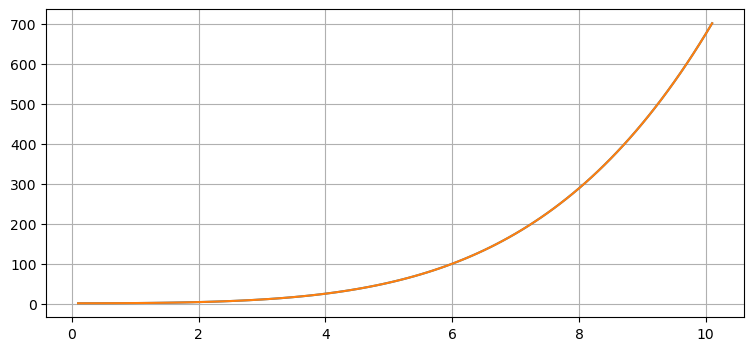

In [21]:
import math
import numpy as np
t = 0.
y = 1.
dt = .1

ys, ts = [], []

def func(y,t):
    return t*math.sqrt(y)

while t <= 10:
    y = runge_kutta4(y, t, dt, func)
    t += dt
    ys.append(y)
    ts.append(t)

exact = [(t**2 + 4)**2 / 16. for t in ts]
plt.plot(ts, ys)
plt.plot(ts, exact)

error = np.array(exact) - np.array(ys)
print(f"max error {max(error):.5f}")

## 贝叶斯滤波（Bayesian Filtering）

从 **离散贝叶斯（Discrete Bayes）** 一章起，我用贝叶斯表述做滤波。假设跟踪某物体。我们把特定时刻的 *状态（state）* 定义为其位置、速度等。例如，$t$ 时刻状态可写为 $\mathbf x_t = \begin{bmatrix}x_t &\dot x_t \end{bmatrix}^\mathsf T$。

测量物体时，测量的是状态或其一部分。传感器有噪声，故测量被噪声污染。显然，测量由状态决定：状态变化可能改变测量，但测量变化不会改变状态。

滤波目标是：从 0 到 $t$ 时刻的状态集 $\mathbf x_{0:t}$ 计算最优估计。若已知 $\mathbf x_{0:t}$，计算对应测量集 $\mathbf z_{0:t}$ 就平凡。但我们收到 $\mathbf z_{0:t}$，要计算对应状态 $\mathbf x_{0:t}$。这称为 *统计反演（statistical inversion）*，因为从输出求输入。

反演困难，因为通常无唯一解。对给定 $\mathbf x_{0:t}$ 只有一组可能测量（加噪声），但对给定测量，可有多种状态集产生那些测量。

回忆贝叶斯定理（Bayes' theorem）：

$$P(x \mid z) = \frac{P(z \mid x)P(x)}{P(z)}$$

其中 $P(z \mid x)$ 是测量 $z$ 的 *似然（likelihood）*，$P(x)$ 是基于过程模型的 *先验（prior）*，$P(z)$ 是归一化常数。$P(x \mid z)$ 是 *后验（posterior）*，即纳入测量 $z$ 后的分布，也称 *证据（evidence）*。

这是 *统计反演*，因为从 $P(z \mid x)$ 到 $P(x \mid z)$。滤波问题的解可表为：

$$P(\mathbf x_{0:t} \mid \mathbf z_{0:t}) = \frac{P(\mathbf z_{0:t} \mid \mathbf x_{0:t})P(\mathbf x_{0:t})}{P(\mathbf z_{0:t})}$$

这很好，直到下一测量 $\mathbf z_{t+1}$ 到来，此时需对 $0:t+1$ 全范围重算整个表达式。

实践中这不可行，因为我们在求全时间步上状态的后验分布 $P(\mathbf x_{0:t} \mid \mathbf z_{0:t})$。但我们通常并不关心刚收到第十个测量时第三步的概率分布。因此我们放宽要求，只计算当前时间步的分布。

第一个简化是把过程（如运动物体的运动模型）描述为 *马尔可夫链（Markov chain）*：当前状态仅依赖前一状态与转移概率 $P(\mathbf x_k \mid \mathbf x_{k-1})$，即从上一状态到当前状态的概率。写作：

$$\mathbf x_k \sim P(\mathbf x_k \mid \mathbf x_{k-1})$$

实践中这极其合理，许多事物具有 *马尔可夫性质（Markov property）*。若在停车场开车，下一秒位置是否依赖一分钟前你是从州际公路下来还是在土路上爬行？不。下一秒位置只依赖当前位置、速度与控制输入，不依赖一分钟前发生的事。故汽车有马尔可夫性质，我们可无精度或一般性损失地做此简化。

下一个简化是把 *测量模型（measurement model）* 定义为依赖当前状态 $\mathbf x_k$，条件概率为给定当前状态的测量：$P(\mathbf z_k \mid \mathbf x_k)$。写作：

$$\mathbf z_k \sim P(\mathbf z_k \mid \mathbf x_k)$$

现在有递推，需要初值终止。故说初始分布是状态 $\mathbf x_0$ 的概率：

$$\mathbf x_0 \sim P(\mathbf x_0)$$


这些项代入贝叶斯方程。若有 $\mathbf x_0$ 与第一个测量，可估计 $P(\mathbf x_1 | \mathbf z_1)$。运动模型产生先验 $P(\mathbf x_2 \mid \mathbf x_1)$。再代入贝叶斯定理算 $P(\mathbf x_2 | \mathbf z_2)$。继续该预测-校正算法，仅根据 $t-1$ 的状态与分布及 $t$ 的测量，递归计算 $t$ 的状态与分布。

该计算的数学细节因问题而异。**离散贝叶斯** 与 **一维卡尔曼滤波（Univariate Kalman Filter）** 两章给出两种不同表述，你应能推理理解。一维卡尔曼滤波假设标量状态的过程与噪声模型均受零均值、不相关高斯噪声影响的线性模型。

多元卡尔曼滤波（Multivariate Kalman filter）做同样假设，但状态与测量为向量而非标量。卡尔曼博士证明，若这些假设成立，卡尔曼滤波在最小二乘（least squares）意义下是 *最优（optimal）* 的。通俗说，无法从含噪测量中提取更多信息。本书其余部分将介绍放松线性与高斯噪声约束的滤波器。

继续之前，再谈统计反演。如 Calvetti 与 Somersalo 在 *Introduction to Bayesian Scientific Computing* 中所写：“我们采用贝叶斯观点：*随机性 simply 意味着信息不足*[3]”。状态参数化原则上可测量或计算的现象：速度、空气阻力等。我们信息不足，无法计算或测量其值，故把它们视为随机变量。严格说它们并非随机，故这是主观立场。

他们专章讨论该主题。我可 spare 一段。贝叶斯滤波可行，因为我们对未知参数赋予统计性质。对卡尔曼滤波，有闭式解求最优估计。其他滤波器，如离散贝叶斯滤波或后文粒子滤波（particle filter），以更随意、非最优方式建模概率。我们技巧的力量来自：把信息不足视为随机变量，用概率分布描述，再用贝叶斯定理解统计推断问题。



## 将卡尔曼滤波化为 g-h 滤波（Converting Kalman Filter to a g-h Filter）

我说过卡尔曼滤波是 g-h 滤波（g-h filter）的一种形式。只需一些代数即可证明。一维情形更直接，故在此证明。回忆

$$
\mu_{x}=\frac{\sigma_1^2 \mu_2 + \sigma_2^2 \mu_1} {\sigma_1^2 + \sigma_2^2}
$$

为便于阅读写成：

$$
\mu_{x}=\frac{ya + xb} {a+b}
$$

用下列代数可轻松写成 g-h 形式

$$
\begin{aligned}
\mu_{x}&=(x-x) + \frac{ya + xb} {a+b} \\
\mu_{x}&=x-\frac{a+b}{a+b}x  + \frac{ya + xb} {a+b} \\ 
\mu_{x}&=x +\frac{-x(a+b) + xb+ya}{a+b} \\
\mu_{x}&=x+ \frac{-xa+ya}{a+b}  \\
\mu_{x}&=x+ \frac{a}{a+b}(y-x)\\
\end{aligned}
$$

几乎完成，但回忆估计方差为

$$\begin{aligned}
\sigma_{x}^2 &= \frac{1}{\frac{1}{\sigma_1^2} +  \frac{1}{\sigma_2^2}} \\
&= \frac{1}{\frac{1}{a} +  \frac{1}{b}}
\end{aligned}$$

观察可得

$$ 
\begin{aligned}
\frac{a}{a+b} &= \frac{a/a}{(a+b)/a} = \frac{1}{(a+b)/a}  \\
 &= \frac{1}{1 + \frac{b}{a}} = \frac{1}{\frac{b}{b} + \frac{b}{a}}  \\
 &= \frac{1}{b}\frac{1}{\frac{1}{b} + \frac{1}{a}} \\
 &= \frac{\sigma^2_{x}}{b}
 \end{aligned}
$$

综合得

$$
\begin{aligned}
\mu_{x}&=x+ \frac{a}{a+b}(y-x) \\
&= x + \frac{\sigma^2_{x}}{b}(y-x) \\
&= x + g_n(y-x)
\end{aligned}
$$

其中

$$g_n = \frac{\sigma^2_{x}}{\sigma^2_{y}}$$

结果是两测量残差乘以常数再加到前值——正是 g-h 滤波的 $g$ 方程。$g$ 是新估计方差除以测量方差。当然这里 $g$ 非常数，随方差变化而变。同样可推导 $h$ 公式，推导不特别启发，略过。结果是

$$h_n = \frac{COV (x,\dot x)}{\sigma^2_{y}}$$

要点是：$g$ 与 $h$ 完全由时刻 $n$ 的测量与预测的方差和协方差确定。换言之，我们按两项输入质量决定的缩放因子，在测量与预测之间选点。



## 参考文献（References）


 * [1] C.B. Molwer and C.F. Van Loan "Nineteen Dubious Ways to Compute the Exponential of a Matrix, Twenty-Five Years Later,", *SIAM Review 45, 3-49*. 2003.


 * [2] C.F. van Loan, "Computing Integrals Involving the Matrix Exponential," IEEE *Transactions Automatic Control*, June 1978.
 
 
 * [3] Calvetti, D and Somersalo E, "Introduction to Bayesian Scientific Computing: Ten Lectures on Subjective Computing,", *Springer*, 2007.
 
 * [4] Brown, R. G. and Hwang, P. Y.C., "Introduction to Random Signals and Applied Kalman Filtering", *Wiley and Sons*, Fourth Edition, p.143-147, 2012. 
 

